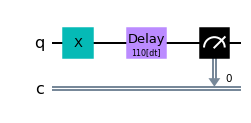

In [1]:
from qiskit import circuit, transpile
from qiskit.test.mock import FakeArmonk

backend = FakeArmonk()

qc = circuit.QuantumCircuit(1, 1)
qc.x(0)
qc.delay(110, 0, unit="dt")
qc.measure(0, 0)
qc.draw('mpl')

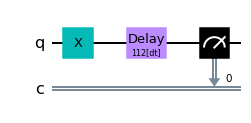

In [2]:
qct = transpile(qc, backend, scheduling_method='alap',
                timing_constraints={'acquire_alignment': 16})
qct.draw('mpl')

In [3]:
from qiskit import QuantumCircuit
circuit = QuantumCircuit(2)
circuit.h([0, 1])
other = QuantumCircuit(2)
other.x([0, 1])
print(circuit.compose(other, wrap=True))  # wrapped
print(circuit.compose(other, wrap=False))  # not wrapped

     ┌───┐┌─────────────┐
q_0: ┤ H ├┤0            ├
     ├───┤│  circuit-91 │
q_1: ┤ H ├┤1            ├
     └───┘└─────────────┘
     ┌───┐┌───┐
q_0: ┤ H ├┤ X ├
     ├───┤├───┤
q_1: ┤ H ├┤ X ├
     └───┘└───┘


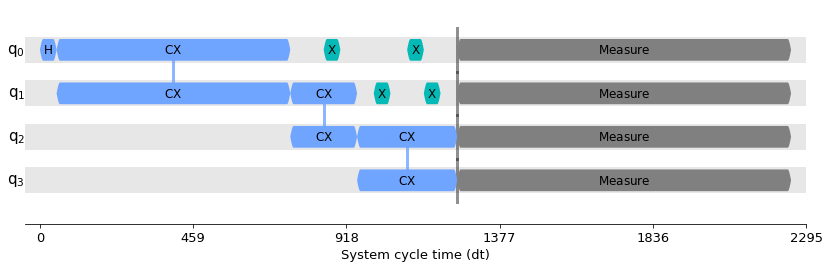

In [4]:
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager, InstructionDurations
from qiskit.transpiler.passes import ALAPSchedule, DynamicalDecoupling
from qiskit.visualization import timeline_drawer

circ = QuantumCircuit(4)
circ.h(0)
circ.cx(0, 1)
circ.cx(1, 2)
circ.cx(2, 3)
circ.measure_all()

durations = InstructionDurations(
    [("h", 0, 50), ("cx", [0, 1], 700), ("reset", None, 10),
     ("cx", [1, 2], 200), ("cx", [2, 3], 300),
     ("x", None, 50), ("measure", None, 1000)]
)

dd_sequence = [XGate(), XGate()]

pm = PassManager([ALAPSchedule(durations),
                  DynamicalDecoupling(durations, dd_sequence)])
circ_dd = pm.run(circ)
timeline_drawer(circ_dd)

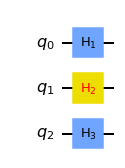

In [5]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import HGate
qc = QuantumCircuit(3)
qc.append(HGate(label='h1'), [0])
qc.append(HGate(label='h2'), [1])
qc.append(HGate(label='h3'), [2])
qc.draw('mpl', style={'displaytext': {'h1': 'H_1', 'h2': 'H_2', 'h3': 'H_3'},
    'displaycolor': {'h2': ('#EEDD00', '#FF0000')}})

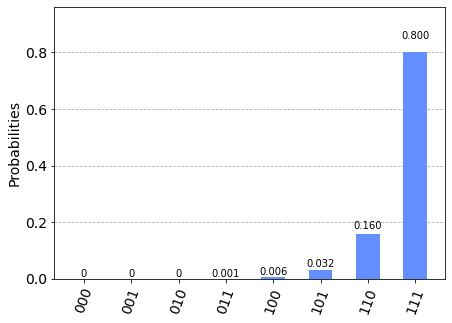

In [6]:
from qiskit.visualization import plot_histogram

counts = {
  '000': 5,
  '001': 25,
  '010': 125,
  '011': 625,
  '100': 3125,
  '101': 15625,
  '110': 78125,
  '111': 390625,
}
plot_histogram(counts, sort='value')

In [7]:
from qiskit import QuantumCircuit

qasm = """OPENQASM 2.0;
include "qelib1.inc";
opaque delay(time) q;
qreg q[1];
delay(172) q[0];
u3(0.1,0.2,0.3) q[0];
"""
circuit = QuantumCircuit.from_qasm_str(qasm)
circuit.draw()

┌────────────────┐┌─────────────────┐
q_0: ┤ Delay(172[dt]) ├┤ U3(0.1,0.2,0.3) ├
     └────────────────┘└─────────────────┘

In [8]:
from qiskit.circuit import Parameter
from qiskit import pulse

shift = Parameter('alpha')

schedule = pulse.Schedule()
schedule += pulse.SetFrequency(shift, pulse.DriveChannel(0))

assert schedule.is_parameterized() == True
print(schedule.parameters)

{Parameter(alpha)}


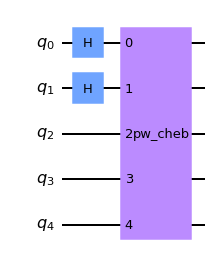

In [9]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library.arithmetic.piecewise_chebyshev import PiecewiseChebyshev
f_x, degree, breakpoints, num_state_qubits = lambda x: np.arcsin(1 / x), 2, [2, 4], 2
pw_approximation = PiecewiseChebyshev(f_x, degree, breakpoints, num_state_qubits)
pw_approximation._build()
qc = QuantumCircuit(pw_approximation.num_qubits)
qc.h(list(range(num_state_qubits)))
qc.append(pw_approximation.to_instruction(), qc.qubits)
qc.draw(output='mpl')

In [10]:
from qiskit.visualization import array_to_latex
from numpy import sqrt, exp, pi
mat = [[0, exp(pi*.75j)],
       [1/sqrt(8), 0.875]]
array_to_latex(mat)

<IPython.core.display.Latex object>

In [11]:
from qiskit.quantum_info import DensityMatrix
dm = DensityMatrix.from_label('r0')
dm.draw('latex')

<IPython.core.display.Latex object>

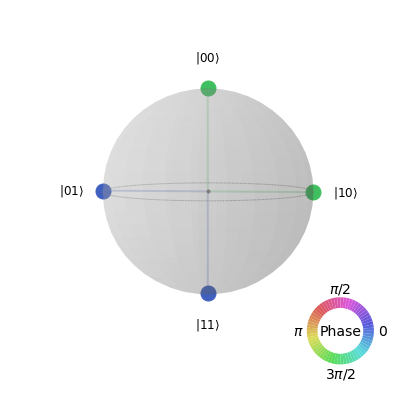

In [12]:
from qiskit.quantum_info import Statevector
sv = Statevector.from_label('+r')
sv.draw('qsphere')

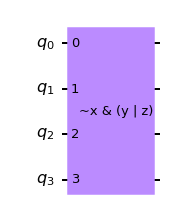

In [13]:
from qiskit.circuit import BooleanExpression, QuantumCircuit

expression = BooleanExpression('~x & (y | z)')
circuit = QuantumCircuit(4)
circuit.append(expression, [0, 1, 2, 3])
circuit.draw('mpl')

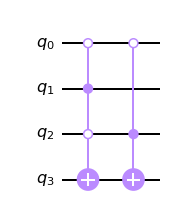

In [14]:
circuit.decompose().draw('mpl')

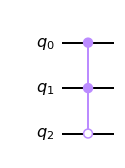

In [15]:
from qiskit.circuit.library.phase_oracle import PhaseOracle

oracle = PhaseOracle('x1 & x2 & (not x3)')
oracle.draw('mpl')

In [16]:
from qiskit.algorithms import AmplificationProblem, Grover
from qiskit import BasicAer

backend = BasicAer.get_backend('qasm_simulator')

problem = AmplificationProblem(oracle, is_good_state=oracle.evaluate_bitstring)
grover = Grover(quantum_instance=backend)
result = grover.amplify(problem)
result.top_measurement

'011'

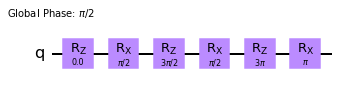

In [17]:
from qiskit import QuantumCircuit
from qiskit.transpiler.passes import BasisTranslator
from qiskit.circuit.equivalence_library import SessionEquivalenceLibrary as sel

circuit = QuantumCircuit(1)
circuit.h(0)

pass_instance = BasisTranslator(sel, ['rx', 'rz', 'cx'])
result = pass_instance(circuit)
result.draw(output='mpl')

In [18]:
from qiskit import QuantumCircuit
from qiskit.transpiler.passes import Depth

circuit = QuantumCircuit(1)
circuit.h(0)

property_set = {}
pass_instance = Depth()
pass_instance(circuit, property_set)
print(property_set)

{'depth': 1}


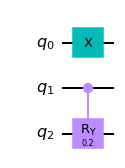

In [19]:
from qiskit import QuantumCircuit
top = QuantumCircuit(1)
top.x(0);
bottom = QuantumCircuit(2)
bottom.cry(0.2, 0, 1);
bottom.tensor(top).draw(output='mpl')

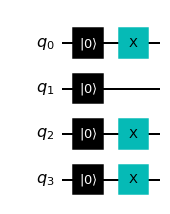

In [20]:
from qiskit.extensions import Initialize

initialize = Initialize(13)
initialize.definition.draw('mpl')

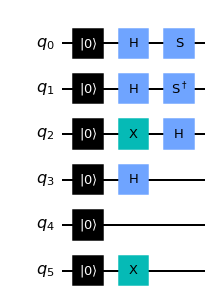

In [21]:
from qiskit.extensions import Initialize

initialize = Initialize("10+-lr")
initialize.definition.draw('mpl')

In [22]:
from qiskit import QuantumCircuit, execute, BasicAer, result
from qiskit.result.utils import marginal_counts
qc = QuantumCircuit(5, 5)
qc.x(0)
qc.measure(0, 0)

result = execute(qc, BasicAer.get_backend('qasm_simulator')).result()
print(marginal_counts(result.get_counts(), [0, 2, 4], format_marginal=True))

{'0_0_1': 1024}


In [23]:
from qiskit.quantum_info import Pauli

P1 = Pauli('XYZ')
P2 = Pauli('YZX')
P1.dot(P2)

Pauli('-iZXY')

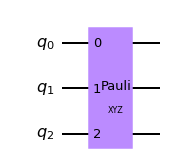

In [24]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli

circ = QuantumCircuit(3)
circ.append(Pauli('XYZ'), [0, 1, 2])
circ.draw(output='mpl')

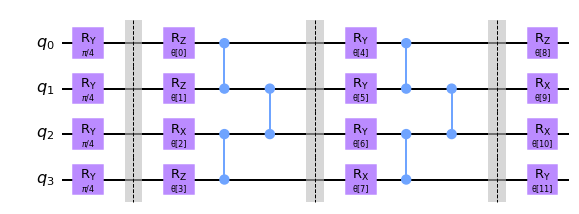

In [25]:
from qiskit.circuit.library import PauliTwoDesign
circuit = PauliTwoDesign(4, reps=2, seed=5, insert_barriers=True)
circuit.decompose().draw(output='mpl')

In [26]:
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector

circ = QFT(3)

state1 = Statevector.from_instruction(circ)
state2 = Statevector.from_instruction(circ.reverse_bits())

state1.reverse_qargs() == state2

True

In [27]:
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Operator

circ = QFT(3)

op1 = Operator(circ)
op2 = Operator(circ.reverse_bits())

op1.reverse_qargs() == op2

True

ParameterView([Parameter(x), Parameter(y)])


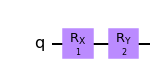

In [28]:
from qiskit.circuit import QuantumCircuit, Parameter

circuit = QuantumCircuit(1)
circuit.rx(Parameter('x'), 0)
circuit.ry(Parameter('y'), 0)

print(circuit.parameters)

bound = circuit.bind_parameters([1, 2])
bound.draw(output='mpl')

In [29]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

statevector = Statevector(qc)
statevector.draw(output='latex')

<IPython.core.display.Latex object>

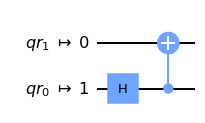

In [30]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.compiler import transpile

qr = QuantumRegister(2, name='qr')
circ = QuantumCircuit(qr)
circ.h(qr[0])
circ.cx(qr[0], qr[1])

transpile(circ, initial_layout=[1, 0]).draw(output='mpl')

In [31]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.compiler import transpile

qr = QuantumRegister(2, name='qr')
circ = QuantumCircuit(qr)
circ.h(qr[0])
circ.cx(qr[0], qr[1])

transpile(circ, initial_layout=[4, 2], coupling_map=None).draw()

ancilla_0 -> 0 ──────────
                         
ancilla_1 -> 1 ──────────
                    ┌───┐
     qr_1 -> 2 ─────┤ X ├
                    └─┬─┘
ancilla_2 -> 3 ───────┼──
               ┌───┐  │  
     qr_0 -> 4 ┤ H ├──■──
               └───┘

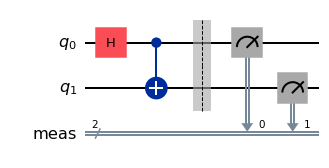

In [32]:
from qiskit.circuit import QuantumCircuit

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()
circuit.draw('mpl', style={'name': 'iqx'})

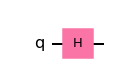

In [33]:
from qiskit.circuit import QuantumCircuit

circuit = QuantumCircuit(1)
circuit.h(0)

style_dict = {'displaycolor': {'h': ('#FA74A6', '#000000')}}
circuit.draw('mpl', style=style_dict)

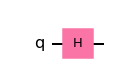

In [34]:
style_dict = {'displaycolor': {'h': '#FA74A6'}}
circuit.draw('mpl', style=style_dict)

In [35]:
from qiskit.circuit import classical_function, Int1

@classical_function
def grover_oracle(a: Int1, b: Int1, c: Int1, d: Int1) -> Int1:
     x = not a and b
     y = d and not c
     z = not x or y
     return z

quantum_circuit = grover_oracle.synth()
quantum_circuit.draw()

q_0: ──■────o────■─────────■───────
       │    │    │         │       
q_1: ──o────┼────┼────■────o────■──
       │    │    │    │    │    │  
q_2: ──┼────┼────o────■────■────┼──
       │    │    │    │    │    │  
q_3: ──o────┼────■────■────■────o──
     ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐
q_4: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├
     └───┘└───┘└───┘└───┘└───┘└───┘

In [36]:
quantum_circuit = grover_oracle.synth(registerless=False)
quantum_circuit.draw()

d_0: ──■────o────■─────────■───────
            │    │    │         │       
     c_0: ──o────┼────┼────■────o────■──
            │    │    │    │    │    │  
     b_0: ──┼────┼────o────■────■────┼──
            │    │    │    │    │    │  
     a_0: ──o────┼────■────■────■────o──
          ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐
return_0: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├
          └───┘└───┘└───┘└───┘└───┘└───┘

In [37]:
circuit = QuantumCircuit(5)
circuit.append(grover_oracle, range(5))
circuit.draw()

┌────────────────┐
q_0: ┤0               ├
     │                │
q_1: ┤1               ├
     │                │
q_2: ┤2 Grover_oracle ├
     │                │
q_3: ┤3               ├
     │                │
q_4: ┤4               ├
     └────────────────┘

In [38]:
circuit.decompose().draw()

q_0: ──■────o────■─────────■───────
       │    │    │         │       
q_1: ──o────┼────┼────■────o────■──
       │    │    │    │    │    │  
q_2: ──┼────┼────o────■────■────┼──
       │    │    │    │    │    │  
q_3: ──o────┼────■────■────■────o──
     ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐
q_4: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├
     └───┘└───┘└───┘└───┘└───┘└───┘

In [39]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1, 1)
qc.delay(500, 0, unit='ns')
qc.measure(0, 0)

qc.draw()

┌────────────────┐┌─┐
q_0: ┤ Delay(500[ns]) ├┤M├
     └────────────────┘└╥┘
c: 1/═══════════════════╩═
                        0

In [40]:
from qiskit import QuantumCircuit, transpile
from qiskit.test.mock.backends import FakeAthens

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

scheduled_circuit = transpile(qc, backend=FakeAthens(), scheduling_method="alap")
print("Duration in dt:", scheduled_circuit.duration)
scheduled_circuit.draw(idle_wires=False)

Duration in dt: 2016


┌─────────┐    ┌────┐┌─────────┐     
q_0 -> 0 ───┤ Rz(π/2) ├────┤ √X ├┤ Rz(π/2) ├──■──
         ┌──┴─────────┴───┐└────┘└─────────┘┌─┴─┐
q_1 -> 1 ┤ Delay(160[dt]) ├─────────────────┤ X ├
         └────────────────┘                 └───┘

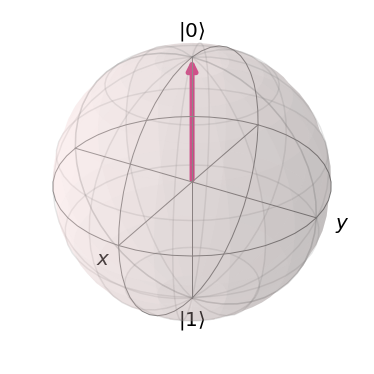

In [41]:
from numpy import pi

from qiskit.visualization import plot_bloch_vector

x = 0
y = 0
z = 1
r = 1
theta = pi
phi = 0


# Cartesian coordinates, where (x,y,z) are cartesian coordinates
# for bloch vector
plot_bloch_vector([x,y,z])

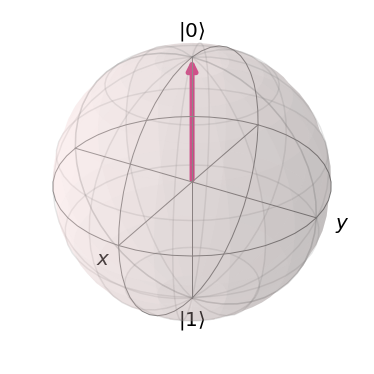

In [42]:
plot_bloch_vector([x,y,z], coord_type="cartesian")  # Same as line above

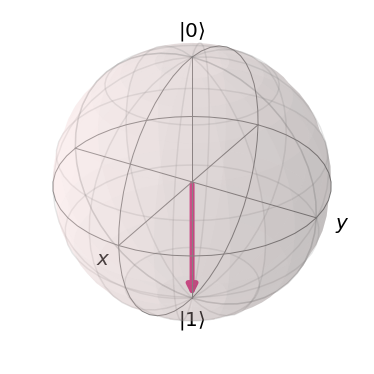

In [43]:
# Spherical coordinates, where (r,theta,phi) are spherical coordinates
# for bloch vector
plot_bloch_vector([r, theta, phi], coord_type="spherical")

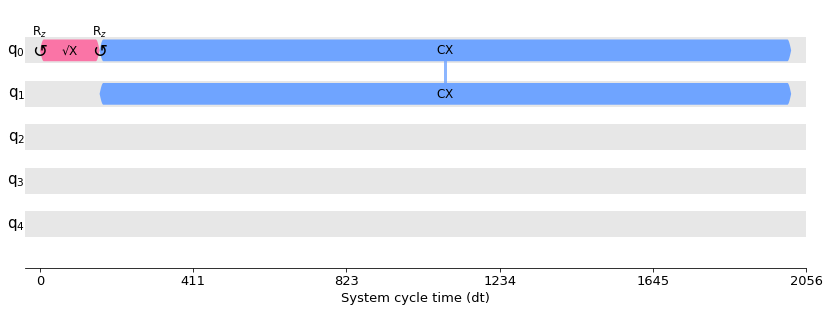

In [44]:
from qiskit.visualization import timeline_drawer
from qiskit import QuantumCircuit, transpile
from qiskit.test.mock import FakeAthens

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
timeline_drawer(transpile(qc, FakeAthens(), scheduling_method='alap'))

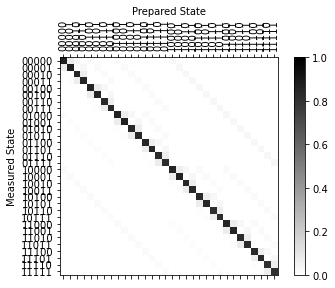

In [45]:
from qiskit import execute
from qiskit.test.mock import FakeVigo
import qiskit.ignis.mitigation as mit

backend = FakeVigo()
num_qubits = backend.configuration().num_qubits

# Generate calibration circuits
circuits, metadata = mit.expval_meas_mitigator_circuits(
    num_qubits, method='tensored')
result = execute(circuits, backend, shots=8192).result()

# Fit mitigator
mitigator = mit.ExpvalMeasMitigatorFitter(result, metadata).fit()

# Plot fitted N-qubit assignment matrix
mitigator.plot_assignment_matrix()

In [46]:
from qiskit import QuantumCircuit

# Test Circuit with expectation value -1.
qc = QuantumCircuit(num_qubits)
qc.x(range(num_qubits))
qc.measure_all()

# Execute
shots = 8192
seed_simulator = 1999
result = execute(qc, backend, shots=8192, seed_simulator=1999).result()
counts = result.get_counts(0)

# Expectation value of Z^N without mitigation
expval_nomit, error_nomit = mit.expectation_value(counts)
print('Expval (no mitigation): {:.2f} \u00B1 {:.2f}'.format(
    expval_nomit, error_nomit))

# Expectation value of Z^N with mitigation
expval_mit, error_mit = mit.expectation_value(counts,
    meas_mitigator=mitigator)
print('Expval (with mitigation): {:.2f} \u00B1 {:.2f}'.format(
    expval_mit, error_mit))

Expval (no mitigation): -0.66 ± 0.01
Expval (with mitigation): -1.01 ± 0.01


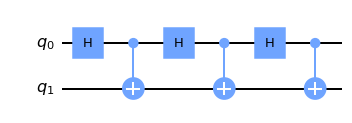

In [47]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
repeated_qc = qc.repeat(3)
repeated_qc.decompose().draw(output='mpl')

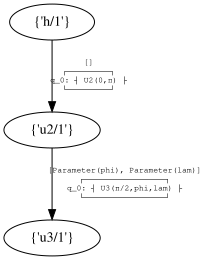

In [48]:
from numpy import pi

from qiskit.circuit import EquivalenceLibrary
from qiskit.circuit import QuantumCircuit
from qiskit.circuit import QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import HGate
from qiskit.circuit.library import U2Gate
from qiskit.circuit.library import U3Gate

my_equiv_library = EquivalenceLibrary()

q = QuantumRegister(1, 'q')
def_h = QuantumCircuit(q)
def_h.append(U2Gate(0, pi), [q[0]], [])
my_equiv_library.add_equivalence(HGate(), def_h)

theta = Parameter('theta')
phi = Parameter('phi')
lam = Parameter('lam')
def_u2 = QuantumCircuit(q)
def_u2.append(U3Gate(pi / 2, phi, lam), [q[0]], [])
my_equiv_library.add_equivalence(U2Gate(phi, lam), def_u2)

my_equiv_library.draw()

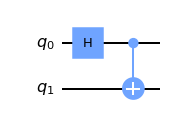

In [49]:
from qiskit.circuit import QuantumCircuit

circ1 = QuantumCircuit(2)
circ2 = QuantumCircuit(2)

circ2.h(0)
circ1.cx(0, 1)

circ1.compose(circ2, front=True).draw(output='mpl')

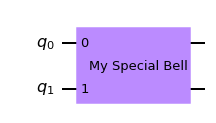

In [50]:
from qiskit.circuit import QuantumCircuit

circuit_gate = QuantumCircuit(2)
circuit_gate.h(0)
circuit_gate.cx(0, 1)
custom_gate = circuit_gate.to_gate(label='My Special Bell')
new_circ = QuantumCircuit(2)
new_circ.append(custom_gate, [0, 1], [])
new_circ.draw(output='mpl')

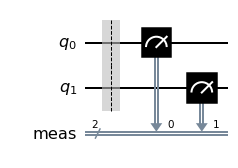

In [51]:
from qiskit import QuantumCircuit
circuit = QuantumCircuit(2)
circuit.measure_all()
circuit.draw(output='mpl', cregbundle=True)

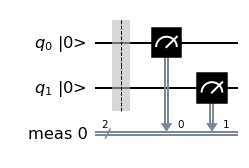

In [52]:
from qiskit import QuantumCircuit
circuit = QuantumCircuit(2)
circuit.measure_all()
circuit.draw(output='mpl', initial_state=True)

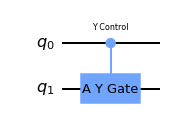

In [53]:
from qiskit import QuantumCircuit
from qiskit.circuit.library.standard_gates import YGate
circuit = QuantumCircuit(2)
circuit.append(YGate(label='A Y Gate').control(label='Y Control'), [0, 1])
circuit.draw(output='mpl')

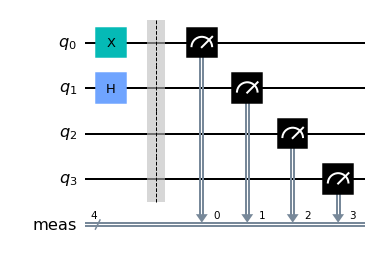

In [54]:
from qiskit.circuit import QuantumCircuit

circ = QuantumCircuit(4)
circ.x(0)
circ.h(1)
circ.measure_all()
circ.draw(output='mpl')

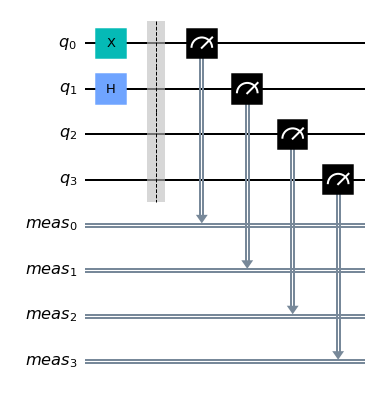

In [55]:
from qiskit.circuit import QuantumCircuit

circ = QuantumCircuit(4)
circ.x(0)
circ.h(1)
circ.measure_all()
circ.draw(output='mpl', cregbundle=False)

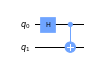

In [56]:
from qiskit import QuantumCircuit
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.draw(output='mpl', scale=0.5)

In [57]:
from qiskit.circuit.library import XOR
import qiskit.tools.jupyter
circuit = XOR(5, seed=42)
%circuit_library_info circuit

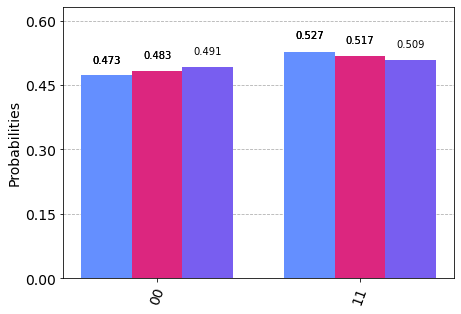

In [58]:
from qiskit import execute
from qiskit import QuantumCircuit
from qiskit.providers.basicaer import BasicAer
from qiskit.visualization import plot_histogram

sim = BasicAer.get_backend('qasm_simulator')

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
result = execute([qc, qc, qc], sim).result()

plot_histogram(result.get_counts())

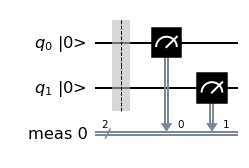

In [59]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(2)
circuit.measure_all()
circuit.draw(output='mpl', initial_state=True)

In [60]:
from qiskit.quantum_info import Statevector

state = Statevector.from_label('+0')
print(state.to_dict())

{'00': (0.7071067811865475+0j), '10': (0.7071067811865475+0j)}


In [61]:
from qiskit.quantum_info import DensityMatrix

state = DensityMatrix.from_label('+0')
print(state.to_dict())

{'00|00': (0.4999999999999999+0j), '10|00': (0.4999999999999999+0j), '00|10': (0.4999999999999999+0j), '10|10': (0.4999999999999999+0j)}


In [62]:
from qiskit.quantum_info import Statevector

state = Statevector.from_label('+0')
print(state.probabilities())

[0.5 0.  0.5 0. ]


In [63]:
from qiskit.quantum_info import DensityMatrix

state = DensityMatrix.from_label('+0')
print(state.probabilities())

[0.5 0.  0.5 0. ]


In [64]:
from qiskit.quantum_info import Statevector

state = Statevector.from_label('+0')
print(state.probabilities_dict())

{'00': 0.4999999999999999, '10': 0.4999999999999999}


In [65]:
from qiskit.quantum_info import DensityMatrix

state = DensityMatrix.from_label('+0')
print(state.probabilities_dict())

{'00': 0.4999999999999999, '10': 0.4999999999999999}


In [66]:
from qiskit.quantum_info import Statevector

psi = Statevector.from_label('+0')
shots = 1024

# Sample counts dictionary
counts = psi.sample_counts(shots)
print('Measure both:', counts)

# Qubit-0
counts0 = psi.sample_counts(shots, [0])
print('Measure Qubit-0:', counts0)

# Qubit-1
counts1 = psi.sample_counts(shots, [1])
print('Measure Qubit-1:', counts1)

Measure both: {'00': 514, '10': 510}
Measure Qubit-0: {'0': 1024}
Measure Qubit-1: {'0': 508, '1': 516}


In [67]:
from qiskit.quantum_info import Statevector

psi = Statevector.from_label('-1')
shots = 10

# Sample memory
mem = psi.sample_memory(shots)
print('Measure both:', mem)

# Qubit-0
mem0 = psi.sample_memory(shots, [0])
print('Measure Qubit-0:', mem0)

# Qubit-1
mem1 = psi.sample_memory(shots, [1])
print('Measure Qubit-1:', mem1)

Measure both: ['11' '01' '01' '11' '11' '11' '01' '01' '01' '11']
Measure Qubit-0: ['1' '1' '1' '1' '1' '1' '1' '1' '1' '1']
Measure Qubit-1: ['1' '1' '1' '1' '0' '0' '1' '1' '1' '0']


In [68]:
from qiskit.quantum_info import Statevector

psi = Statevector.from_label('+1')

# Measure both qubits
outcome, psi_meas = psi.measure()
print("measure([0, 1]) outcome:", outcome, "Post-measurement state:")
print(psi_meas)

# Measure qubit-1 only
outcome, psi_meas = psi.measure([1])
print("measure([1]) outcome:", outcome, "Post-measurement state:")
print(psi_meas)

measure([0, 1]) outcome: 11 Post-measurement state:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))
measure([1]) outcome: 0 Post-measurement state:
Statevector([-0.+0.j,  1.+0.j, -0.+0.j,  0.+0.j],
            dims=(2, 2))


In [69]:
from qiskit.quantum_info import Statevector

psi = Statevector.from_label('+1')

# Reset both qubits
psi_reset = psi.reset()
print("Post reset state: ")
print(psi_reset)

# Reset qubit-1 only
psi_reset = psi.reset([1])
print("Post reset([1]) state: ")
print(psi_reset)

Post reset state: 
Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
Post reset([1]) state: 
Statevector([-0.+0.j,  1.+0.j, -0.+0.j,  0.+0.j],
            dims=(2, 2))


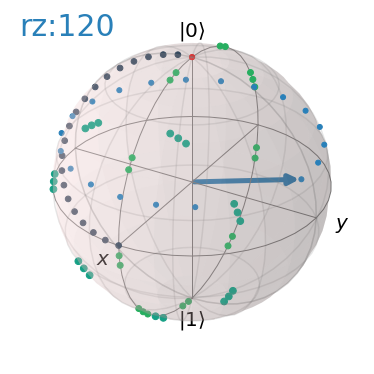

In [70]:
from qiskit.visualization import visualize_transition
from qiskit import *

qc = QuantumCircuit(1)
qc.h(0)
qc.ry(70,0)
qc.rx(90,0)
qc.rz(120,0)

visualize_transition(qc, fpg=20, spg=1, trace=True)

In [71]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(2)
circuit.measure_all()
circuit.draw(output='text')

░ ┌─┐   
   q_0: ─░─┤M├───
         ░ └╥┘┌─┐
   q_1: ─░──╫─┤M├
         ░  ║ └╥┘
meas: 2/════╩══╩═
            0  1

In [72]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(2)
circuit.measure_all()
circuit.draw(output='text', initial_state=True)

░ ┌─┐   
  q_0: |0>─░─┤M├───
           ░ └╥┘┌─┐
  q_1: |0>─░──╫─┤M├
           ░  ║ └╥┘
meas: 0 2/════╩══╩═
              0  1

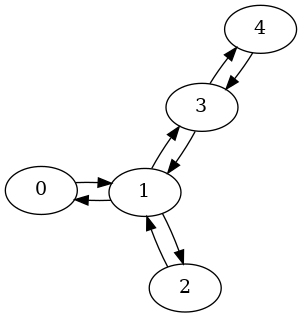

In [73]:
from qiskit.transpiler import CouplingMap

coupling_map = CouplingMap(
    [[0, 1], [1, 0], [1, 2], [1, 3], [2, 1], [3, 1], [3, 4], [4, 3]])
coupling_map.draw()

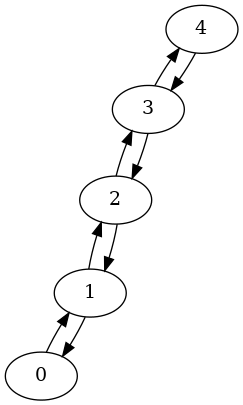

In [74]:
from qiskit.transpiler import CouplingMap

coupling_map = CouplingMap.from_line(5)
coupling_map.draw()

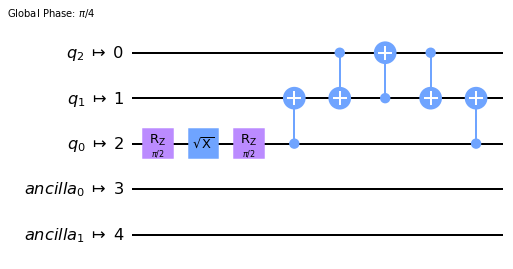

In [75]:
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.test.mock import FakeVigo

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
transpiled_qc = transpile(qc, FakeVigo())
transpiled_qc.draw(output='mpl')

/opt/hostedtoolcache/Python/3.8.12/x64/lib/python3.8/site-packages/qiskit/pulse/schedule.py:1657: DeprecationWarning: Legacy pulse drawer is deprecated. Specified arguments show_framechange_channels are deprecated. Please check the API document of new pulse drawer `qiskit.visualization.pulse_drawer_v2`.
  warnings.warn(


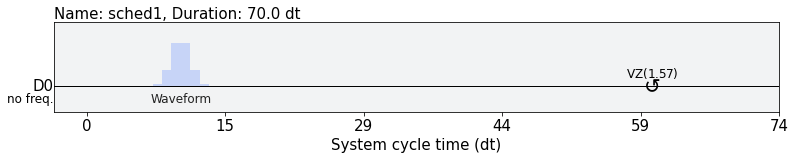

In [76]:
from qiskit.pulse import *
from qiskit.pulse import library as pulse_lib

gp0 = pulse_lib.gaussian(duration=20, amp=1.0, sigma=1.0)
sched = Schedule()
channel_a = DriveChannel(0)
channel_b = DriveChannel(1)
sched += Play(gp0, channel_a)
sched = sched.insert(60, ShiftPhase(-1.57, channel_a))
sched = sched.insert(30, ShiftPhase(-1.50, channel_b))
sched = sched.insert(70, ShiftPhase(1.50, channel_b))

sched.draw(show_framechange_channels=False)